# fMRI preprocessing pipeline 
<p style="font-size:smaller; color: gray;">created on 23.12.2024, last updated on 10.04.2026</p>

This is a hands on guide on how to preprocess your fMRI data using python based [docker containers](#2.-What-is-Docker-and-how-to-install-it). We start absolutely from scratch. Starting with just your raw DICOM files you get directly from the scanner, this guide will teach you step by step how to convert your data to the **BIDS format**, check your data quality, and then run all required preprocessing steps required for further fMRI data analyses.
<br>All code will be provided in a template format where you will, for the most part, only have to adjust a few file locations. The only part where you *might* have to make a few more extra adjustments depending on your experimental setup is for converting your raw data into **BIDS**. 
<br> So in general, even though this guide contains bash and python scripts, only moderate coding experience should be required to run the pipeline.

# Table of Contents
[1. Preface](#1.-Preface)

[2. What is Docker and how to install it](#2.-What-is-Docker-and-how-to-install-it)

[3. Setting up your raw data](#3.-Setting-up-your-raw-data)

[4. Converting your data to BIDS: Heudiconv](#4.-Converting-your-data-to-BIDS:-Heudiconv)

[5. Preprocessing your data: fmriPrep](#5.-Preprocessing-your-data:-fmriPrep)

[6. Pydeface: Defacing your T1w](#6.-Pydeface:-Defacing-your-T1w)

[7. Smoothing your data and extracting binarized anatomical masks](#7.-Smoothing-your-data-and-extracting-binarized-anatomical-masks)

# 1. Preface
## BIDS: A standardized data structure
The Brain Imaging Data Structure [**BIDS**](https://bids.neuroimaging.io/) is a standardized data structure for your fMRI data. Virtually every python-based preprocessing or analysis tool requires your data to be in **BIDS** format. But even if you do not plan on using python for your analyses, **BIDS** offers you an extremely clear overview of your data. By the process of standardization, it also basically removes the need of any form of exception handling due to arbitrary variations in your collected data, such as scan sequences that had to be restarted due to technical difficulties. Furthermore, **BIDS** is nowadays more or less standard in the scientific community, so using **BIDS** makes it much easier to compare your data and analyses to others' research or share it with whomever. 
<br>**Furthermore**, it makes [prepocessing](#5.-Preprocessing-your-data:-fmriPrep) of your data a piece of cake! 

## How to use this guide 
Originally, this guide was supposed to only cover the basics, such as converting your data into the **BIDS** format, preprocess everything using *fmriPrep*, etc. These things are fairly straightforward, and are covered in detail from [2. What is Docker and how to install it](#2.-What-is-Docker-and-how-to-install-it)( [3. Setting up your raw data](#3.-Setting-up-your-raw-data) until [5. Preprocessing your data: fmriPrep](#5.-Preprocessing-your-data:-fmriPrep) using example data sets from my own project. With this guide, these steps are easy to perform and only require minimal to no coding experience in Python. As for other preprocessing steps such as defacing or smoothing, these can be done much more easily in other software such as Matlab SPM.
<br>However, this guide also offers a few follow up steps beyond the scope of this workshop, such as [defacing](#6.-Pydeface:-Defacing-your-T1w) or [smoothing data in native space](#7.-Smoothing-your-data-and-extracting-binarized-anatomical-masks). These steps will require you to properly set up a linux backend for IDEs such as Visual Studio Code, assume higher python coding proficiency, and you will even need to learn some things about [Graph Theory](https://miykael.github.io/nipype-beginner-s-guide/nipype.html). Like mentioned, however, this workshop will focus in BIDS conversion and preprocessing using fmriPrep.

# 2. What is Docker and how to install it
To run any of the fMRI preprocessing pipeline, we first need to install **Docker** and set up its required virtual environment. **Docker** is a software that uses a **linux virtual environment** (i.e., the **backend**)<sup>1</sup> to run so called containers. **Containers** are sets of tools (e.g., python environments) that can be ran from any PC using docker. That way, you don't need to manually install all packages required for specific tools. For instance, to convert your data to BIDS, you can use the [*heudiconv* container](#4.-Converting-your-data-to-BIDS:-Heudiconv).

<br><p style="font-size:smaller; color: gray;"><sup>1</sup>Don't worry, you will need little to no knowledge of linux to run this pipeline ;)

## Setting up our linux backend
We will first need to set up the **linux backend** for Docker, which is also fairly straightforward if you know what to do. We will use *Ubuntu* for our backend.

<br>Open up powershell as admin. Type this:

```bash
dism.exe /online /enable-feature /featurename:Microsoft-Windows-Subsystem-Linux /all /norestart
dism.exe /online /enable-feature /featurename:VirtualMachinePlatform /all /norestart
```

<br>Then restart your PC. After that, we can install the WSL. Open Powershell again as admin. Type:

```bash
wsl --install -d Ubuntu
```

<br>If everything worked correctly, simply type:

``` bash
wsl --list --verbose
```

<br>It should then look like this:

```bash
  NAME              STATE           VERSION
* Ubuntu            Running         2
```

<br>As you can see, *Ubuntu* is indeed running. We can now install Docker. In Poweshell type
```bash
wsl
```
<br>If you are running wsl correctly, it should then look something like this:
```bash
bbc9148@UN-WKS-018970:/mnt/uhhdisk$
```
<br>Follow the installation guide from the [docker documentation](https://docs.docker.com/engine/install/ubuntu/) (no clue what the individual code lines do though lol):

```bash
# Add Docker's official GPG key:
sudo apt update
sudo apt install ca-certificates curl
sudo install -m 0755 -d /etc/apt/keyrings
sudo curl -fsSL https://download.docker.com/linux/ubuntu/gpg -o /etc/apt/keyrings/docker.asc
sudo chmod a+r /etc/apt/keyrings/docker.asc

# Add the repository to Apt sources:
sudo tee /etc/apt/sources.list.d/docker.sources <<EOF
Types: deb
URIs: https://download.docker.com/linux/ubuntu
Suites: $(. /etc/os-release && echo "${UBUNTU_CODENAME:-$VERSION_CODENAME}")
Components: stable
Signed-By: /etc/apt/keyrings/docker.asc
EOF

sudo apt update

sudo apt install docker-ce docker-ce-cli containerd.io docker-buildx-plugin docker-compose-plugin
sudo usermod -aG docker $USER
newgrp docker
```
<br> Confirm Docker is running correctly by typing this:
```bash
docker run hello-world
```
<br>It should now Pull the hello-world image. We are now ready to install HeuDiConv! If it not working, open up your wsl config:

```bash
sudo nano /etc/wsl.conf
```
<br> Add this in there:

```
[boot]
systemd=true
```

<br> Docker should now work properly. We will need to allocate some memory to our wsl for these pipelines to work properly next.

## Allocating memory to the wsl
If you have a rather weak device, these pipelines might crash. Still, we can manually allocate more memory to the wsl to make crashes less likely. Open up a new powershell. **Do not enter the wsl**. Instead, type
```bash
cd C:\Users\<your_username
notepad .wslconfig
```
<br>A notepad window will pop up. Add this inside
```bash
[wsl2]
memory=7GB
processors=4
swap=2GB
```
<br>Adjust memory to your system specifications. You can see them if you search for system information in the windows searchbar. You should see \<total physical memory> there somewhere. If you have more than 8Gb, set memory to 8GB. If you 8GB or less, set it to Maximum-1GB. To check if it worked, restart wsl
```bash
wsl --shutdown
wsl
```
<br>Then type
```bash
free -h
```
<br>You should see something like 
```bash
               total        used        free      shared  buff/cache   available
Mem:           7.6Gi       451Mi       7.0Gi       3.4Mi       339Mi       7.2Gi
Swap:          2.0Gi          0B       2.0Gi
```
<br>**Note**: If you have less than 8Gb, fmriprep might crash. This means your device is unfortunately too weak to run this pipeline. Still, you can follow all steps here to learn how to set up the pipeline.

# 3. Setting up your raw data
Even though the use of **BIDS** conform data is very standardized, actually getting your raw DICOMS (or in your case .IMA, which is a slight variation of DICOMS) into **BIDS** is not. However, if you follow a few rules of structuring your raw files, even this is fairly easy.
<br>**IMPORTANT**: Since setting up your raw data is done manually, I **strongly** encourage you to begin doing this already from your very first participant onwards. It will only take a couple of extra minutes longer and will save you **a lot** of headaches if you just do it after every single participant instead of doing all participants at once after you finished data collection (trust me on this).

## What your raw data immediately after you finished scanning looks like
Once you dowloaded the example data set provided for this workshop, you will be met with a data strcuture like this:

```bash
├───sub-098
│   ├───EP2D_BOLD_RESTING_STATE_0005
│   ├───EP2D_BOLD_RECALL_0009
│   ├───T1_MPRAGE_COR_0016
│   └───EP2D_BOLD_RESTING_STATE_0007
├───sub-094
│   ├───EP2D_BOLD_RESTING_STATE_0008
│   ├───T1_MPRAGE_COR_0006
│   ├───EP2D_BOLD_RECALL_0012
│   └───EP2D_BOLD_RESTING_STATE_0010
└───sub-012
    ├───EP2D_BOLD_RESTING_STATE_0006
    ├───EP2D_BOLD_RESTING_STATE_0008
    ├───EP2D_BOLD_RECALL_0011
    ├───EP2D_BOLD_RECALL_0010
    └───T1_MPRAGE_COR_0013
```

<br>\<EP2D_BOLD> refers to my bold sequences where a recall and two resting state scans were performed. \<T1_MPRAGE> is an anatomical scan. The structure for your own data should be similar; \<EP2D_BOLD> for task data, \<T1_MPRAGE> for anatomical scans. You will probably also have other data in there, such as \<AAHSCOUT> or \<GRE_FIELD_MAPPING>,
<br> As you can see, some bold sequences were repeated. For the resting state scans, that is to be expected, because I had two runs of resting state scans. However, there are also two recall folders for sub-012. This is due to some technical issued where the scanning sequence had to be repeated. The aborted scan sequence is still saved to your data folder. You can tell which one the correct scan by the number at the end. 11 > 10, so this is the last time the recall scanning sequence was started, thus, it is the correct folder. Artefacts like \<EP2D_BOLD_RECALL_0010> should be removed from your data structure to avoid confusion.

### First task: Prepare data structure for BIDS conversion
**HeuDiConv**, the tool we will use for BIDS conversion, will use the folder names , specifically the string after \<_BOLD_> for extracting the task name for the functional scans. As I said, the data set here consisted of of two resting state scans (pre and post) and a recall. Your task is to now rename the folders so the structure is ready for BIDS conversion. 

In the end, it should look like this:

```bash
├───sub-098
│   ├───EP2D_BOLD_1_RESTING_STATE_0005
│   ├───EP2D_BOLD_RECALL_0009
│   ├───T1_MPRAGE_COR_0016
│   └───EP2D_BOLD_2_RESTING_STATE_0007
├───sub-094
│   ├───EP2D_BOLD_1_RESTING_STATE_0008
│   ├───T1_MPRAGE_COR_0006
│   ├───EP2D_BOLD_RECALL_0012
│   └───EP2D_BOLD_2_RESTING_STATE_0010
└───sub-012
    ├───EP2D_BOLD_1_RESTING_STATE_0006
    ├───EP2D_BOLD_2_RESTING_STATE_0008
    ├───EP2D_BOLD_RECALL_0011
    └───T1_MPRAGE_COR_0013
```
The number right after \<BOLD_> specifies the run number of that sequence. This will be used in the HeuDiConv heuristic. **Protip**: If you want to be smarter than me, specify the run number already directly in the scanning sequence names at the MRI PC, e.g., \<1_RESTING_> and \<2_RESTING>. That way, you will not have to manually specify it as your raw DICOM folders will already be named accourdingly.

### Restructure your data: Multiple MRI sessions and multiple runs
Note that I only had one MRI session per participant in my study. If you have multiple MRI sessions and multiple runs per task, you should restructure your data to something like this:

```bash
├───sub-070_1
│   ├───EP2D_BOLD_1_RESTING_STATE_0008
│   ├───T1_MPRAGE_COR_0006
│   ├───EP2D_BOLD_RECALL_0012
│   └───EP2D_BOLD_2_RESTING_STATE_0010
├───sub-070_2
│   ├───EP2D_BOLD_1_RESTING_STATE_0005
│   ├───EP2D_BOLD_RECALL_0009
│   ├───T1_MPRAGE_COR_0016
│   └───EP2D_BOLD_2_RESTING_STATE_0007
```

HeuDiConv can then make use of the session indicator and create a session-value key-value pair in the format of \<sub-XX_ses-XX_>. 

If you have your dataset in a structure similar to the ones described above, your data is ready for this pipeline. In the next part, we will set up our PC to run the pipeline.

# 4. Converting your data to BIDS: Heudiconv
Now that you got your data ready and set up Docker correctly, you are ready to convert your data into **BIDS**! For this, we will use the docker container [*heudiconv*](https://heudiconv.readthedocs.io/en/latest/index.html). In short, *heudiconv* will get your raw fMRI data in .IMA format and convert it into .nii.gz files. This is also great because instead of having hundreds of single volumes, you will get one single .nii.gz file per task (in 4d format)! 
<br>Furthermore, once everything is set up to **BIDS**, the actual preprocessing using [*fmriPrep*](#5.-Preprocessing-your-datta:-fmriPrep), will be super easy. So let's get started.

## Install heudiconv and how it works
<br>First, make sure the latest version of *heudiconv* is installed. For that, in your wsl, run this:

```bash
docker pull nipy/heudiconv:latest
```

<br>*Heudiconv* uses a python-based heuristic file to know exactly what to name your .nii.gz files and where to save them. In general, the the heuristic file should look create a format like this to be **BIDS** conform:

<br>For BOLD sequences: sub-\<yourID>\_ses-\<yourSession>\_task-\<yourTask>\_run-\<yourRun>\_bold.nii.gz
<br>For T1w: sub-\<yourID>\_T1w.nii.gz

<br>**Note**: If you only have one session per subject, you won't have the ses- key. 

## Setting up our heurtisic file
We first need to set up a heuristics file which heudiconv will use to know how to convert your raw data sets. We will first create an empty template. In your wsl, head to the directory where the dataset is saved. For example, if it is saved in C://fmriprep_workshop/Datasets, type:
```bash
cd /mnt/c/fmriprep_workshop/Datasets
```
<br>Next, we will run HeuDiConv without converting anything so we get an empty heuristic.py template. Type:
```bash
docker run --rm -it \
  --user "$(id -u):$(id -g)" \
  -v "$PWD:$PWD" \
  -w "$PWD" \
  nipy/heudiconv:latest \
  --files "$PWD"/sub-098/*/*.IMA \
  -o "$PWD"/Nifti \
  -f convertall \
  -s 098 \
  -c none
```
<br>Crucial is the flag -c which specifies if a conversion is hapenning. For now, we do not need any conversion. After docker has finished, you should have a folder Nifti in ./Datasets. But first, create a folder named BIDS in .Datasets. Inside, create a folder ./Datasets/BIDS/Code. We will save the heuristic.py we will create in a second in there.
<br>Now head to ./Datasets/Nifti/.heudiconv/098/info. Copy the heuristic.py to ./Datasets/BIDS/Code. We will modify this file in Visual Studio code. For this, first install [python](https://www.python.org/downloads/windows/) (64bit) our your PC.  
<br>After you installed python, navigate to BIDS/code in your wsl:
```bash
cd /mnt/c/fmriprep_workshop/dataset/bids/code
```
<br>To launch VS Code, simply type
```bash
code .
```
<br>A VS code window should now open up. Trust authors, then double click on heuristic.py. Press Ctrl+shift+p, then Python:Select Interpreter > Select your global python version. Note that it's recommended to create virtual environments for projects. We do not need it here though and is a pain in wsl.
<br>Open up a new terminal at the Terminal tab above.
<br>Your code will look like this:


```python
from __future__ import annotations

import logging
from typing import Optional

from heudiconv.utils import SeqInfo

lgr = logging.getLogger("heudiconv")


def create_key(
    template: Optional[str],
    outtype: tuple[str, ...] = ("nii.gz",),
    annotation_classes: None = None,
) -> tuple[str, tuple[str, ...], None]:
    if template is None or not template:
        raise ValueError("Template must be a valid format string")
    return (template, outtype, annotation_classes)


def infotodict(
    seqinfo: list[SeqInfo],
) -> dict[tuple[str, tuple[str, ...], None], list[str]]:
    """Heuristic evaluator for determining which runs belong where

    allowed template fields - follow python string module:

    item: index within category
    subject: participant id
    seqitem: run number during scanning
    subindex: sub index within group
    """

    data = create_key("run{item:03d}")
    info: dict[tuple[str, tuple[str, ...], None], list[str]] = {data: []}

    for s in seqinfo:
        """
        The namedtuple `s` contains the following fields:

        * total_files_till_now
        * example_dcm_file
        * series_id
        * dcm_dir_name
        * unspecified2
        * unspecified3
        * dim1
        * dim2
        * dim3
        * dim4
        * TR
        * TE
        * protocol_name
        * is_motion_corrected
        * is_derived
        * patient_id
        * study_description
        * referring_physician_name
        * series_description
        * image_type
        """

        info[data].append(s.series_id)
    return info
```

The custimization will happen in \<def infotodict>. For now, delete this at the top:
```python
from heudiconv.utils import SeqInfo
```
<br>And add this
```python
import os
```
<br>Change this
```python
def infotodict(
    seqinfo: list[SeqInfo],
) -> dict[tuple[str, tuple[str, ...], None], list[str]]:
    """Heuristic evaluator for determining which runs belong where

    allowed template fields - follow python string module:

    item: index within category
    subject: participant id
    seqitem: run number during scanning
    subindex: sub index within group
    """

    data = create_key("run{item:03d}")
    info: dict[tuple[str, tuple[str, ...], None], list[str]] = {data: []}

    for s in seqinfo:
        """
        The namedtuple `s` contains the following fields:

        * total_files_till_now
        * example_dcm_file
        * series_id
        * dcm_dir_name
        * unspecified2
        * unspecified3
        * dim1
        * dim2
        * dim3
        * dim4
        * TR
        * TE
        * protocol_name
        * is_motion_corrected
        * is_derived
        * patient_id
        * study_description
        * referring_physician_name
        * series_description
        * image_type
        """

        info[data].append(s.series_id)
    return info
```
<br>To this
```python
def infotodict(seqinfo)
    info = {}
    subject = '098'
    for s in seqinfo:
        info[data].append(s.series_id)
    return info
```
<br>So basically delete the comments and define subject. For now, it will be hardcoded to sub-098, but for the actual conversion, we will later use the all sub-XXX IDs. We also initialize a dictionary info. More on that later
<br>In order to debug the script, we will set some fake parameters so we can actually run the script. We will delete those once we are done. Copy this at the end of your script:
```python
from dataclasses import dataclass
 
@dataclass
class FakeSeqInfo:
    series_id: int
    dcm_dir_name: str
    protocol_name: str = ""

seqinfo = [
    FakeSeqInfo(series_id=1, dcm_dir_name="T1_MPRAGE_COR_0016"),
    FakeSeqInfo(series_id=2, dcm_dir_name="EP2D_BOLD_RECALL_0009"),
    FakeSeqInfo(series_id=3, dcm_dir_name="EP2D_BOLD_1_RESTING_STATE_0005"),
    FakeSeqInfo(series_id=3, dcm_dir_name="EP2D_BOLD_2_RESTING_STATE_0007")
]

info = infotodict(seqinfo)
print(info)
```
<br>The whole script should now look like this:
```python
from __future__ import annotations

import logging
from typing import Optional


lgr = logging.getLogger("heudiconv")
import os


def create_key(
    template: Optional[str],
    outtype: tuple[str, ...] = ("nii.gz",),
    annotation_classes: None = None,
) -> tuple[str, tuple[str, ...], None]:
    if template is None or not template:
        raise ValueError("Template must be a valid format string")
    return (template, outtype, annotation_classes)


def infotodict(seqinfo):
    info = {}
    subject = '098'
    for s in seqinfo:
        info[data].append(s.series_id)
    return info

from dataclasses import dataclass
 
@dataclass
class FakeSeqInfo:
    series_id: int
    dcm_dir_name: str
    protocol_name: str = ""

seqinfo = [
    FakeSeqInfo(series_id=1, dcm_dir_name="T1_MPRAGE_COR_0016"),
    FakeSeqInfo(series_id=2, dcm_dir_name="EP2D_BOLD_RECALL_0009"),
    FakeSeqInfo(series_id=3, dcm_dir_name="EP2D_BOLD_1_RESTING_STATE_0005"),
    FakeSeqInfo(series_id=3, dcm_dir_name="EP2D_BOLD_2_RESTING_STATE_0007")
]

info = infotodict(seqinfo)
print(info)
```


<br>We will now make use of the folder names, as all required information is in there<sup>3</sup>. 
\<s> is the iterator over our scanning sequences. s.dcm_dir_name contains our folder names. We will use the prefix to determine if it is a t1 scan or an episcan:
```python
def infotodict(seqinfo):
    info = {}
    subject = '098'
    for s in seqinfo:
        if 'T1' in s.dcm_dir_name:
            data = create_key(f'sub-{subject}/anat/sub-{subject}_T1w')
        info[data].append(s.series_id)
    return info
```
<br>So if the T1 prefix is in the file name, convert the output under ./anat/sub-{subject}_T1w. For functional scans, things are a bit more complicated. We need to determin whether there are multiple runs per task or not (and if so, specify which scan is which run) and specify the task name. Luckily, this is also in our folder names:
```bash
"EP2D_BOLD_RECALL_0009"
"EP2D_BOLD_1_RESTING_STATE_0005"
```
So if there is a digit after \<BOLD_>, we know this is the run indicator. And we have the task name in there as well, which is awesome. To make use of this, we will split the folder name into its substrings. Also, we add the condition by which HeuDiConv will that the file is an epi sequence
```python
def infotodict(seqinfo):
    info = {}
    subject = '098'
    for s in seqinfo:
        if 'T1' in s.dcm_dir_name:
            data = create_key(f'sub-{subject}/anat/sub-{subject}_T1w')
        elif 'EP2D' in s.dcm_dir_name:
            parts = s.dcm_dir_name.split('_')
        info[data].append(s.series_id)
    return info
```
<br>So we split between the underscores. This will leave us with a list like this
```bash
['EP2D', 'BOLD', '1', 'RESTING', 'STATE', '0005']
```
<br>Now we simply check if the string after BOLD is a digit (i.e., run indicator) or not. So we check the third string, which is parts\[2] (Python starts counting from 0. We can then use this to specify the run number. The fourth string (parts\[3]) is then the task name. If we only have one run, the task name will be the third string (parts\[2]). Finally, we put the task string into lower cases so it will say task-resting and not task-RESTING.
```python
def infotodict(seqinfo):
    info = {}
    subject = '098'
    for s in seqinfo:
        if 'T1' in s.dcm_dir_name:
            data = create_key(f'sub-{subject}/anat/sub-{subject}_T1w')
        elif 'EP2D' in s.dcm_dir_name:
            parts = s.dcm_dir_name.split('_')
            if parts[2].isdigit():
                run = parts[2]
                task = parts[3]
                data = create_key(f'sub-{subject}/func/sub-{subject}_task-{task}_run-{run}_bold')
            else:
                task = parts[2]
                data = create_key(f'sub-{subject}/func/sub-{subject}_task-{task}_bold')
        info[data].append(s.series_id)
    return info
```
<br>Functional sequences will now be saved under ./func, and task name, as well as run number (if available) will be indicated. We are now basically done with setting up the heuristic! Add this at the end
```python
if data not in info:
    info[data] = []
info[data].append(s.series_id)
````
<br>Your finished file should look like this
```python
from __future__ import annotations

import logging
from typing import Optional


lgr = logging.getLogger("heudiconv")
import os


def create_key(
    template: Optional[str],
    outtype: tuple[str, ...] = ("nii.gz",),
    annotation_classes: None = None,
) -> tuple[str, tuple[str, ...], None]:
    if template is None or not template:
        raise ValueError("Template must be a valid format string")
    return (template, outtype, annotation_classes)


def infotodict(seqinfo):
    info = {}
    subject = '098'
    for s in seqinfo:
        if 'T1' in s.dcm_dir_name:
            data = create_key(f'sub-{subject}/anat/sub-{subject}_T1w')
        elif "EP2D" in s.dcm_dir_name:
            parts = s.dcm_dir_name.split('_')
            if parts[2].isdigit():
                run = parts[2]
                task = parts[3].lower()
                data = create_key(f"sub-{subject}/func/sub-{subject}_task-{task}_run-{run}_bold")
            else:
                task = parts[2].lower()
                data = create_key(f"sub-{subject}/func/sub-{subject}_task-{task}_bold")
        if data not in info:
            info[data] = []
        info[data].append(s.series_id)
    return info

from dataclasses import dataclass
 
@dataclass
class FakeSeqInfo:
    series_id: int
    dcm_dir_name: str
    protocol_name: str = ""

seqinfo = [
    FakeSeqInfo(series_id=1, dcm_dir_name="T1_MPRAGE_COR_0016"),
    FakeSeqInfo(series_id=2, dcm_dir_name="EP2D_BOLD_RECALL_0009"),
    FakeSeqInfo(series_id=3, dcm_dir_name="EP2D_BOLD_1_RESTING_STATE_0005"),
    FakeSeqInfo(series_id=3, dcm_dir_name="EP2D_BOLD_2_RESTING_STATE_0007")
]

info = infotodict(seqinfo)
print(info)
```
<br> Now simply run the script. If you have done everything correctly, it should show this in the terminal:
```bash
{('sub-098/anat/sub-098_T1w', ('nii.gz',), None): [1], ('sub-098/func/sub-098_task-recall_bold', ('nii.gz',), None): [2], ('sub-098/func/sub-098_task-resting_run-1_bold', ('nii.gz',), None): [3], ('sub-098/func/sub-098_task-resting_run-2_bold', ('nii.gz',), None): [3]}
```
<br>Finally, delete this as we are done with debugging.
```python
from dataclasses import dataclass
 
@dataclass
class FakeSeqInfo:
    series_id: int
    dcm_dir_name: str
    protocol_name: str = ""

seqinfo = [
    FakeSeqInfo(series_id=1, dcm_dir_name="T1_MPRAGE_COR_0016"),
    FakeSeqInfo(series_id=2, dcm_dir_name="EP2D_BOLD_RECALL_0009"),
    FakeSeqInfo(series_id=3, dcm_dir_name="EP2D_BOLD_1_RESTING_STATE_0005"),
    FakeSeqInfo(series_id=3, dcm_dir_name="EP2D_BOLD_2_RESTING_STATE_0007")
]

info = infotodict(seqinfo)
print(info)
```
<br>Also, set subject to this
```python
subject = os.getenv("HEUDICONV_SUBJECT")
```

<br>Now that we finished our heuristic.py, we can finally set up a script to run HeuDiConv! Luckily, this is pretty straightforward.

<br><p style="font-size:smaller; color: gray;"><sup>3</sup>This is why it is crucial that when naming your folders. **Else, it will not be BIDS conform**

## Heuristic file for a study with multiple sessions

### Study Overview

We're now going to walk through an example heuristic for a **multi-session (multi-day) study**, similar to what you might encounter in a real project (e.g., Sterre's project).

In this type of study, each participant is scanned on **two separate days**, and we want to automatically organize all collected data into a clean, **BIDS-compliant structure** using *HeuDiConv*.

- **Session 01 (Day 1)**: Initial scans and neurofeedback runs  
- **Session 02 (Day 2)**: Follow-up scans, additional tasks, and fewer neurofeedback runs  

The goal of this heuristic is (again) to translate scanner folder names into meaningful BIDS labels (e.g., task names, run numbers, session labels).

---

### Anatomical Scans

Let's start with the structural data.

Each session includes:

- A **T1-weighted (MPRAGE)** scan: your main anatomical reference  
- Optionally, a **high-resolution hippocampal scan** (T2-weighted)  

In the heuristic, we detect these scans based on their folder names and assign them to the `anat/` directory with the appropriate labels.

---

### Functional Runs

Now for the more complex part: the functional (fMRI) data.

Here, we rely heavily on **folder naming conventions** to determine:
- Which **task** a run belongs to  
- Which **run number** it should get  

---

#### Resting-State (TEMP)

We treat all folders containing `"TEMP"` as resting-state runs (`task-rest`):

- **Session 01**: One run  
- **Session 02**: Two runs  

For Session 02, we explicitly map folder suffixes:
- `0007` > `run-01`  
- `0014` > `run-02`  

This ensures consistent run numbering even if the scanner naming is not intuitive.

---

#### Neurofeedback Runs (RTNF_0)

Folders containing `"RTNF_0"` correspond to **neurofeedback runs** (`task-NF`):

- **Session 01**: Up to 4 runs  
- **Session 02**: Up to 2 runs  

Instead of hardcoding run numbers, we **extract them directly from the folder name** (e.g., `RTNF_01`, `RTNF_02`). This makes the heuristic more flexible and reusable.

---

#### Reactivity Run (RTNF_REACT)

This is a special case:

- Only present in **Session 02**  
- Always labeled as **`run-07`**  

Why run-07? This keeps it consistently ordered after the neurofeedback runs, regardless of how many were collected.

---

#### Working Memory Task (WPT)

Folders containing `"WPT"` correspond to a separate task:

- Only present in **Session 02**  
- Up to 4 runs  

Again, run numbers are taken directly from the folder name.

---

### Data Handling Rules

A few important rules are built into the heuristic:

- Any folder containing `"old"` is **skipped**  
  * This prevents accidentally including repeated or discarded scans  

- If a folder name doesn't match expectations, it is **ignored with a warning**  
  * This helps you catch inconsistencies without breaking the whole conversion  

---

### Environment Variables

Before running this heuristic, you must again define:

- `SUBJECT_ID` : the participant ID  
- `SESSION_NUM` : the session (`"01"` or `"02"`)  

These are used to construct the final BIDS paths like: sub-01/ses-01/func/sub-01_ses-01_task-rest_bold.nii.gz   
### Why This Matters

In multi-session studies, things can get messy quickly:
- Different numbers of runs per day  
- Slightly inconsistent naming from the scanner  
- Multiple task types  

This heuristic helps standardize everything by:

- Enforcing **consistent naming**  
- Automatically assigning **tasks and run numbers**  
- Making your dataset **analysis-ready**

As you go through the code below, try to connect each `if` statement to the rules described here: this will help you understand how raw data gets translated into BIDS.


In [ ]:
from __future__ import annotations
import logging
from typing import Optional
from heudiconv.utils import SeqInfo
import os

lgr = logging.getLogger("heudiconv")

def create_key(
        template: Optional[str],
        outtype: tuple[str, ...] = ("nii.gz",),
        annotation_classes: None = None,
) -> tuple[str, tuple[str, ...], None]:
    if template is None or not template:
        raise ValueError("Template must be a valid format string")
    return (template, outtype, annotation_classes)


def infotodict(seqinfo):
    """Heuristic evaluator for determining which runs belong where"""
    info = {}
    
    ## Make sure that each subject has only 4 NF runs on day 1; 2 NF runs on day 2 (and 1 REACT)
    ## Make sure that each subject has only 4 WPT runs on day 2;
    ## Make sure that each EPI_TEMP on day 2 is called either EPI_TEMP_0007 or EPI_TEMP_0014

    # Get the subject and session from environment variables
    subject = os.getenv("SUBJECT_ID")
    session = os.getenv("SESSION_NUM")
    if not subject:
        raise ValueError("No subject ID (SUBJECT_ID) has been specified!")
    if not session:
        raise ValueError("No session number (SESSION_NUM) has been specified!")

    for s in seqinfo:
        parts = s.dcm_dir_name.split("_")

        # Handle T1w scans
        if 'T1_MPRAGE_COR_ND' in s.dcm_dir_name:
            task = 'T1w'
            data = create_key(f"sub-{subject}/ses-{session}/anat/sub-{subject}_ses-{session}_T1w")
            if data not in info:
                info[data] = []
            info[data].append(s.series_id)
            
        # Handle high res hippocampal scans
        if 'HIGHRESHIPPOCAMPUS' in s.dcm_dir_name:
            task = 'T1'
            data = create_key(f"sub-{subject}/ses-{session}/anat/sub-{subject}_ses-{session}_acq-highreshp_T2w")
            if data not in info:
                info[data] = []
            info[data].append(s.series_id)
            
        if 'TEMP' in s.dcm_dir_name:
            task = 'rest'
            
            if 'old' in s.dcm_dir_name:
                lgr.info(f"Skipping folder containing 'old': {s.dcm_dir_name}")
                continue

            if session == '01':
                data = create_key(f"sub-{subject}/ses-{session}/func/sub-{subject}_ses-{session}_task-{task}_bold")
                if data not in info:
                    info[data] = []
                info[data].append(s.series_id)

            elif session == '02':
                try:
                    if parts[2] == '0007':
                        run = '01'
                    elif parts[2] == '0014':
                        run = '02'
                    else:
                        lgr.warning(f"Unexpected run value {parts[2]} in TEMP folder: {s.dcm_dir_name}. Skipping.")
                        continue
                    data = create_key(f"sub-{subject}/ses-{session}/func/sub-{subject}_ses-{session}_task-{task}_run-{run}_bold")
                    if data not in info:
                        info[data] = []
                    info[data].append(s.series_id)
                except IndexError:
                    lgr.warning(f"Unexpected folder format for TEMP: {s.dcm_dir_name}. Skipping.")
                    continue
            
        # Handle multiple RTNF_0 runs
        if 'RTNF_0' in s.dcm_dir_name:
            task = 'NF'

            if 'old' in s.dcm_dir_name:
                lgr.info(f"Skipping folder containing 'old': {s.dcm_dir_name}")
                continue

            # Extract run number from folder name dynamically
            try:
                run = parts[2]  # Assuming the run number is the second part (e.g., RTNF_01 -> 01)
                if not run.isdigit():
                    lgr.warning(f"Run number is not numeric in folder {s.dcm_dir_name}. Skipping.")
                    continue
                run = f"{int(run):02}"  # Ensure zero-padded run number
                data = create_key(
                    f"sub-{subject}/ses-{session}/func/sub-{subject}_ses-{session}_task-{task}_run-{run}_bold"
                )
                if data not in info:
                    info[data] = []
                info[data].append(s.series_id)
            except IndexError:
                lgr.warning(f"Unexpected folder format for RTNF_0: {s.dcm_dir_name}. Skipping.")
                continue

        # Handle RTNF_REACT
        if 'RTNF_REACT' in s.dcm_dir_name:
            
            if 'old' in s.dcm_dir_name:
                lgr.info(f"Skipping folder containing 'old': {s.dcm_dir_name}")
                continue
            
            task = 'NF'
            data = create_key(f"sub-{subject}/ses-{session}/func/sub-{subject}_ses-{session}_task-{task}_run-07_bold")
            if data not in info:
                info[data] = []
            info[data].append(s.series_id)

        # Handle WPT
        if 'WPT' in s.dcm_dir_name:
            
            if 'old' in s.dcm_dir_name:
                lgr.info(f"Skipping folder containing 'old': {s.dcm_dir_name}")
                continue
            
            task = 'WPT'
            if len(parts) > 2:  # Check if parts[2] exists
                run = parts[2]
                data = create_key(f"sub-{subject}/ses-{session}/func/sub-{subject}_ses-{session}_task-{task}_run-{run}_bold")
                if data not in info:
                    info[data] = []
                info[data].append(s.series_id)
            else:
                lgr.warning(f"Unexpected WPT folder format: {s.dcm_dir_name}. Skipping.")
                continue

    return info


## Setting up our shell script to run heudiconv
To loop *heudiconv* across all your participants, we will need to set up a simple shell script. In this shell script, we will dynamically specify our input directory (i.e., our raw data) for each participant, set global variables such as the subject ID or session ID that will be used in heudiconv_heuristic.py, and then finally run *heudiconv* for each participant. Note that the output directory will not be set dynamically, as this will be done in the heudiconv_heuristic.py. Let's dive into the actual shell script. 

```bash
#!/bin/bash

# Directory containing the data (modify this to your actual path)

# Set this to your raw data directory. Note: since we are using 
# /mnt, windows drive letters such as H: must be lower case. 
# Example: data_dir="/mnt/c/fmriprep_workshop/datasets/"
data_dir="/mnt/<your raw data root folder>"


# Extract the the digits of sub-xxx to determine subject number
for subject_session_dir in "$data_dir"/sub-*; do
    # Extract the subject from the folder name
    subject=$(basename "$subject_session_dir" | sed -E 's/^sub-([0-9]{3})$/\1/') 
    

    echo "Processing subject: $subject"

    # Determine subject specific file location. This will use the variable 
    # subjects extracted from above
    dicom_dir="/mnt/<your raw data root folder>/sub-${subject}/*/*.IMA"
    echo "Using DICOM directory path: $dicom_dir"

    # Run the Docker command with the corresponding environment variables
    docker run --rm \
        
        # Again determine your raw data location. We will mount it and 
        # call it data which we will use 
        # as the input argument for -d (DICOM directory)
        # Example if located at H:/MRI/raw
        # -v "/mnt/h/MRI/raw
        -v "/mnt/<your raw data root folder>:/data" \ 
        
        # Indicate the location for the heuristic used as the argument 
        # -f (heuristic file location)
        # Example if located at H:/MRI/BIDS/code
        # -v "/mnt/c/fmriprep_workshop/datasets/BIDS/code:/heuristics"
        -v "/mnt/<your BIDS folder location>/code:/heuristics" \

        # Set the output directory where you want your BIDS data saved. 
        # This will be used at the input argument -o
        # Example if located at H:/MRI/BIDS
        # -v "mnt/c/fmriprep_workshop/datasets/BIDS:/outdir"
		-v "/mnt/<your BIDS folder location>:/outdir" \
        --entrypoint "heudiconv" \

        # Use subject as a global variable as well which will be used by 
        # heudiconv_heuristic.py
        -e HEUDICONV_SUBJECT=$subject \
        nipy/heudiconv:latest \

        # Use /data as the argument for -d (but also specify subject as 
        # defined above, /outdir for -o, and /heuristics for -f 
        -d "/data/sub-{subject}/*/*.IMA" \
        -s $subject \
        -o "/outdir" \
        -f "/heuristics/heudiconv_heuristic.py" \
        --overwrite --bids -c dcm2niix
done
```

<br>Adjust the paths as indicated by \<> to your specific file locations. Then save this file as run_heudiconv.sh in BIDS/code. We are now finally done and can start the **BIDS** conversion!

## Run heudiconv
Everything is ready to start your **BIDS** conversion now! To do so is super easy. Go to powershell and start your wsl. Change the working directory to the location where your run_heudiconv.sh is located. This should be \<BIDS/code>. 

```bash
cd /mnt/c/fmriprep_workshop/Datasets/BIDS/code
bash run_heudiconv.sh 
```

<br>If your heuristic.py and run_heudiconv.sh are set up correctly, docker will run *heudiconv* for every participant. In the end, you will have **BIDS** conform data!
<br>If you run into any issues such as missing heuristic module , make sure your paths are correctly referenced in run_heudiconv.sh. Other errors could be parsing errors created by my commenting stuff at the docker run heudiconv --rm, so try commenting them out. If docker says there were 0 sessions to be converted, there is most likely a problem in your heuristic.py. Adjust it if need be.

## Examining the output
Your ./BIDS folder should now contain sub-* folders. They should looke something like this:
```bash
└───sub-098
    │   sub-098_scans.tsv
    │
    ├───anat
    │       sub-098_T1w.json
    │       sub-098_T1w.nii.gz
    │
    └───func
            sub-098_task-recall_bold.json
            sub-098_task-recall_bold.nii.gz
            sub-098_task-recall_events.tsv
            sub-098_task-resting_run-1_bold.json
            sub-098_task-resting_run-1_bold.nii.gz
            sub-098_task-resting_run-1_events.tsv
            sub-098_task-resting_run-2_bold.json
            sub-098_task-resting_run-2_bold.nii.gz
            sub-098_task-resting_run-2_events.tsv
````
<br>The events.tsv files will become very important for your later analyses. In there, you will specify when what happened for how long in your scan, such as stimulus timings. For now though, it is just an empty template. Setting up the events.tsv files is beyond the scope of this workshop. Just know that you will need stimulus onsets etc. from your log files from your tasks. The rest of these files are simply our converted DICOMS (.IMA) into a single .nii.gz file per scan. No preprocessing happened yet. For functional scans, these .nii.gz files are in 4d format, containing the x,y, and z- axes, as well as time.

<br>**Final note**: Running a single participant should take around half an hour or so. After this is finished, we can finally run fmriPrep to finish our preprocessing! Also, good news: Now that your data is **BIDS** conform, this is by far the easiest part in this entire pipeline!


# 5. Preprocessing your data: fmriPrep
Now that your data are **BIDS** conform, you only need to run *fmriprep* to run your preprocessing! This step is super straightforward. For that, we need just need to create a bash script run.fmriprep.sh

## Get a license.txt
You will need a freesurfer license to run *fmriprep*. Go to [this link](https://surfer.nmr.mgh.harvard.edu/registration.html), fill out your information and then download the license. Name it \<license.txt> and save it under fmriPrep/code. Now we are ready to create our shell script to run fmriprep! No need to worry about installing it yet. This will be done by docker automically in our script

## Run fmriprep
We will save a shell script in preprocessed/code that will run fmriPrep across participants. To create that, open a text editor of your choice. Then copy this code:

```bash
#!/bin/bash
##################  User inputs  ########################

# BIDS root (as it exists in WSL)
bids_root_dir="your bids path"

# fMRIPrep output directory 
output_dir="your preprocessed path"

# FreeSurfer license (adjust if you put it somewhere else)
fs_license="${output_dir}/code/license.txt"

for subj_dir in "$bids_root_dir"/sub-012; do
    [ -d "$subj_dir" ] || continue

    subj=$(basename "$subj_dir" | sed 's/^sub-//')
    
    echo "===================================================="
    echo "Running fMRIPrep on participant sub-${subj}"
    echo "===================================================="

    docker run --rm \
      -v "${bids_root_dir}":/data:ro \
      -v "${output_dir}":/out \
      -v "${fs_license}":/opt/freesurfer/license.txt:ro \
      -v /etc/localtime:/etc/localtime:ro \
      --user "$(id -u)":"$(id -g)" \
      nipreps/fmriprep:latest \
      /data /out participant \
      --participant-label "${subj}" \
      --fs-no-reconall \
      --output-spaces MNI152NLin2009cAsym:res-2 \
      --skip-bids-validation \
      --notrack

    # Cleanup after processing
    echo "Cleaning up Docker data for participant sub-${subj}"
    docker system prune -f --volumes
done
```

<br>Adjust the paths as indicated by \<> to your specific file locations. Then save this file as run_fmriprep.sh and save it under the \<preprocessed/code> folder you created. Also do unix conversion if required.

<br>Now we are all set! In your wsl, navigate to your preprocessed/code dir. Then run the file: 

```bash
cd /mnt/c/fmriprep_workshop/Datasets/preprocessed/code
bash run_fmriprep.sh
```

## Some adjustments to the code depending on your needs
If you're not interested in creating anatomical masks, you can  add \<--fs-no-reconall>. This way, it will basically only take half as long per subject. But be warned: You cannot extract anatomical masks in native space using this guide if you skip fs-reconall. 
<br> Furthermore, if you do not wish your normalize your data and instead keep it in native space (important for decoding analyses for instance), substitute \<--output-spaces MNI152NLin2009cAsym:res-2> with \<--output-spaces T1w fsnative fsaverage>.

<br>And this is it! If everything has been done correctly, wsl should now run *fmriPrep* for all your participants. This will take a while though (for me it took around 6h per participant). 
<br>Either way, not it's time to wait. So grab some coffee and celebrate. You've earned it!

## Parallelizing your pipeline
This will need much stronger devices than your laptop or work PC. Fmriprep recommends 8gb memory per subject. Also, I would recommend using at least 4 cores. So if you want to run 3 participants at the same time, you will need at least 25gb RAM and 12 cores. We will first need to adjust our .wslconfig to allocate more memory to it. In powershell (**not** wsl) adjust the config.
```bash
cd C:/Users/\<Your username>
notepad .wslconfig
```
<br>Write this inside:
```bash
memory=24GB
processors=12
swap=2GB
```
<br> Now install the fmriprep container: 
```bash
wsl
docker run nipreps/fmriprep:latest
```

<br> With that done, we will now create a script to run multiple subs at once. Open a texteditor. Add this:
```bash
#!/bin/bash

################## User inputs ########################

# BIDS root (as it exists in WSL)
bids_root_dir="/mnt/c/fmriprep_workshop/datasets/BIDS"

# fMRIPrep output directory
output_dir="/mnt/c/fmriprep_workshop/datasets/preprocessed"

# FreeSurfer license
fs_license="${output_dir}/code/license.txt"

# Number of subjects to run in parallel
N=3

# Per-container resources
NPROCS=4
OMP_NTHREADS=1
MEM_MB=8000

#######################################################

# Find all subject folders and strip "sub-"
mapfile -t subjects < <(
  find "$bids_root_dir" -maxdepth 1 -type d -name 'sub-*' -printf '%f\n' | sed 's/^sub-//' | sort
)

if [ ${#subjects[@]} -eq 0 ]; then
  echo "No subject folders found in $bids_root_dir"
  exit 1
fi

echo "Found ${#subjects[@]} subjects:"
printf '  sub-%s\n' "${subjects[@]}"
echo

for subj in "${subjects[@]}"; do
  echo "===================================================="
  echo "Starting fMRIPrep for sub-${subj}"
  echo "===================================================="

  docker run --rm \
    -v "${bids_root_dir}":/data:ro \
    -v "${output_dir}":/out \
    -v "${fs_license}":/opt/freesurfer/license.txt:ro \
    -v /etc/localtime:/etc/localtime:ro \
    --user "$(id -u)":"$(id -g)" \
    nipreps/fmriprep:latest \
    /data /out participant \
    --participant-label "${subj}" \
    --fs-no-reconall \
    --output-spaces MNI152NLin2009cAsym:res-2 \
    --nprocs "${NPROCS}" \
    --omp-nthreads "${OMP_NTHREADS}" \
    --mem-mb "${MEM_MB}" \
    --low-mem \
    --skip-bids-validation \
    --notrack &

  # Limit number of parallel background jobs
  while [ "$(jobs -r | wc -l)" -ge "$N" ]; do
    wait -n
  done
done

# Wait for remaining jobs
wait

echo "===================================================="
echo "All fMRIPrep jobs finished."
echo "===================================================="
```
<br> N specifies the number of subjects we are doing simultaneously. NPROCS tells docker to use 4 cores per subject. MEM_MB tells it to use 8gb ram per subject. Save the file as something like fmriprep_paralell.sh under preprocessed/code. Convert to unix if needed. Now run it within in your wsl:
```bash
wsl
cd /mnt/c/fmriprep_workshop/preprocessed/code
run fmriprep_paralell.sh
```
<br> Like I said, this strongly depends on the machine you are using. On regular devices, parallelizing is not recommended. If you have high performance PCs, this will speed up your preprocessing significantly (obviously, duh).

# 6. Pydeface: Defacing your T1w
If you want to make your data publicly avaliable<sup>4</sup>, you will need to deface your structural image data to ensure anonymity for your participants. This is luckily very straightforward, as Russ Poldrack (the GOAT) has a docker container for this. Note that you could also create your own python script for this, but that would require installing things like fsl, which is a bit annoying. For more customized processes, you will eventually have to install fsl though. You know the drill. Open a new text document. We will create a new shell script.

```bash
root="/mnt/c/fmriprep_workshop/datasets/preprocessed"

for subj_dir in "$root"/sub-*; do
    subj=$(basename "$subj_dir")

    in_file="$root/$subj/anat/${subj}_desc-preproc_T1w.nii.gz"
    out_dir="$root/$subj/defaced"
    out_file="$out_dir/${subj}_desc-preproc_T1w_defaced.nii.gz"

    mkdir -p "$out_dir"

    if [ ! -f "$in_file" ]; then
        echo "[SKIP] $subj"
        continue
    fi

    echo "[RUN ] $subj"

    docker run --rm \
      -v "$root":/data \
      poldracklab/pydeface \
      pydeface \
      "/data/$subj/anat/${subj}_desc-preproc_T1w.nii.gz" \
      --outfile "/data/$subj/defaced/${subj}_desc-preproc_T1w_defaced.nii.gz" \
      --force

    echo "[DONE] $subj"
done
````
<br> Save it as deface.sh (unix convert if needed) under .preprocessed/code. Now we can run it in our wsl:
```bash
wsl
cd /mnt/c/fmriprep_workshop/datasets/preprocessed/code
run deface.sh
```
<br>Now you should have defaced t1 images under ./preprocessed/sub-*/defaced you can make publicly available!


# 7. Smoothing your data and extracting binarized anatomical masks 
We now begin building our own custom workflows using nipype. As stated in the [beginning](#How-to-use-this-guide), this will be much more complex than the stuff we have been doing so far. Hence, from here on out, I am assuming you are proficient with Python. Assuming you already set up an IDE of your liking such as VS Code, open up the Terminal in VS Code. We will first need to install another tool in the Python version of our wsl backend. 

<br> We will need to install fsl and freesurfer for this to work.

## Install fsl
Installing fsl is in our fsl fairly easy. I recommend [this guide](https://fsl.fmrib.ox.ac.uk/fsl/docs/#/install/windows). Make sure to download the [fsl installer](https://fsl.fmrib.ox.ac.uk/fsldownloads/fslconda/releases/fslinstaller.py) and save it in \<downloads>.

Following this guide, first open *Windows Powershell* as admin. Enter this:

```bash
wsl
sudo apt update
sudo apt -y upgrade
sudo apt-get install dc python3 mesa-utils gedit pulseaudio libquadmath0 libgtk2.0-0 firefox libgomp1
python "/mnt/c/Users/<WindowsUserName>/Downloads/fslinstaller.py"

# Check if installed succesfully using this
echo $FSLDIR
```

## Installing freesurfer
Before we can actually start creating our script, we need to install freesurfer since we will use that to extract our binarized anatomical masks. 
<br> To install freesurfer, first, download the [.tar.gz](https://surfer.nmr.mgh.harvard.edu/fswiki/rel7downloads) file. Note that freesurfer does not run on Windows, so we will again use our wsl. OS will thus be Linux, and the Build Platform will be Ubuntu. After you have downloaded that, start *Powershell* as admin and start the wsl. We will need to untar (fancy word for unpacking) the .tar.gz file at the location where you wish to install freesurfer. We will then add freesufer to the environment variables of our wsl so our wsl actually knows where to search for those functions. Finally, we will need to add our [freesurfer lincense](#Get-a-license.txt) to the installation folder. Here's how you do it:

```bash
wsl
cd /mnt/\<your\_username>/Downloads # Head to the location where you downloaded the .tar.z
sudo mkdir -p /usr/local/freesurfer
sudo tar -xvzf freesurfer-linux-\<Your downloaded freesurfer version>.tar.gz -C /usr/local/freesurfer --strip-components=1 # Adjust version accordingly

# Add freesurfer to the environment variables
export FREESURFER_HOME=/usr/local/freesurfer
source $FREESURFER_HOME/SetUpFreeSurfer.sh
source ~/.bashrc  # or source ~/.zshrc

# Copy the license.txt to the freesurfer installation folder
cp /mnt/h/0_remuns/1_data/mri/fmriprep/license.txt $FREESURFER_HOME # Example where I had it saved before

# Test if the installation was successful
recon-all -version
```

## Install nipype
Also, you will need to create a virtual environment from which to launch and nipype. In your wls, type this:

```bash
python3 -m venv myenv # Call myenv however you want your python environment to be called
source myenv/bin/activate # Activate your newly created python environment
python -m pip install nipype niflow-nipype1-workflows
```

<br>Note that we install nipype not directly on Windows, but rather also in our *Linux* environment. It could be that \<pip install> will not work for you right away. In that case, try to [install pip within wsl](https://stackoverflow.com/questions/37954008/proper-way-to-install-pip-on-ubuntu). If installed correctly, try this:

<br>Besides that, you should not require to install much more for now. Before we get into the actual coding, here's a short introduction about nipype and why it is awesome even though it is intimidating at first.

## Nipype, nodes, and graphs: How a workflow generally works
Nipype is an awesome tool. Basically, it lets you create workflows using different interfaces, such as FSL, freesurfer, or even SPM. What this means in practice is that, theoretically, you could do your smoothing using FSL, your anatocimal mask extracting using freesurfer, and your detrending using SPM<sup>7</sup>. Nipype combines these different interface usages to one single workflow. The basic idea is that you make use of different functions and put them into so called **nodes**. Nodes are then connected to one another where the output of node A serves as the input for node B. Below is an example illustration of the script I created to smooth my data in native space and extract some anatomical masks.
<br>You can ignore the code shown in the cell below. That is just to print out the picture and I have not figured out how to hide the code.


<br><p style="font-size:smaller; color: gray;"><sup>8</sup>Which, is actually exactly what I have done, except for using SPM because I still hate that software.


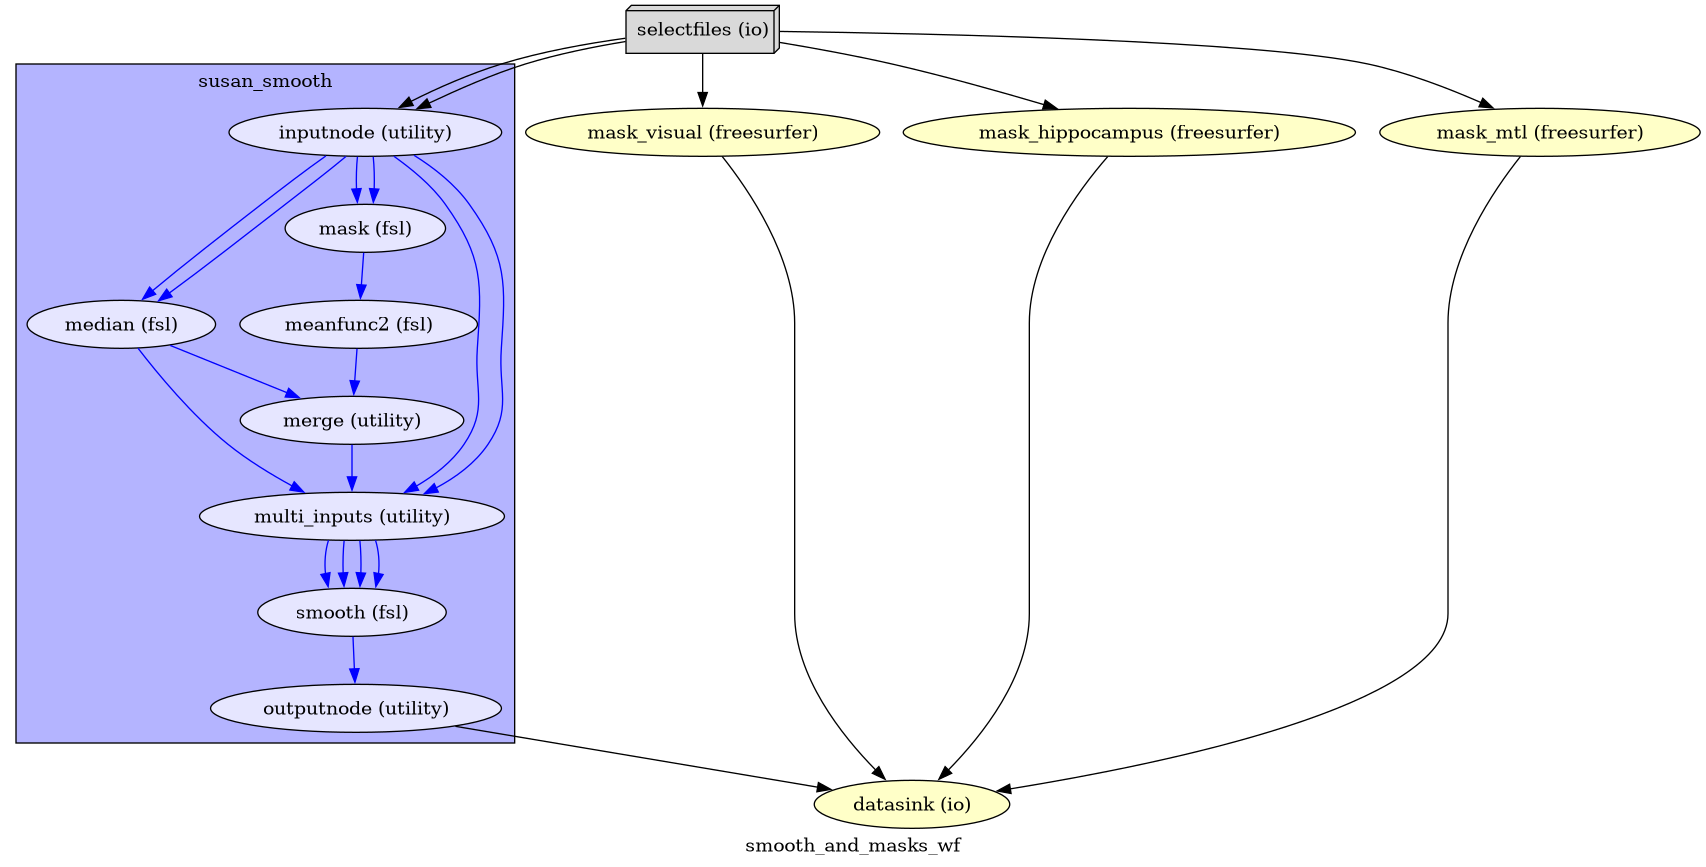

In [ ]:
import base64
from IPython.display import HTML

def img_to_base64(img_path):
    with open(img_path, "rb") as img_file:
        return base64.b64encode(img_file.read()).decode()

# Convert the image to base64
img_data = img_to_base64("Z:/KOPSY/Wiki/fMRI/fmriPrep Preprocessing pipeline/source/graph.png")

# Display the image in the notebook
HTML(f'<img src="data:image/png;base64,{img_data}"/>')

This might look intimidating<sup>8</sup>, but it's actually not that complicated. We first have a selectfiles node. This basically just makes sure to select the proper functional data and the corresponding brain mask to smooth the functional data. This is why there are two arrows pointing towards the susoa_smooth workflow. Specifically, selectfiles outputs a func and a mask file which is then being used as input of the susan_smooth workflow. You don't need to understand what is happening in the susan_smooth workflow by the way. This will be automatically created by the function create_susan_smooth(), but more on that later. selectfiles also outputs some desc-aparcaseg_dseg.nii.gz files that were created in our fmriprep pipeline using fs-reconall (unless you added the --fs-no-reconall flag in the fmriprep script, in which case you won't have these files and will have to comment out this node completely in the script below).
<br>susan_smooth will then use the func and mask file to smooth the functional data. Likewise, the different mask nodes will use the desc-aparcaseg_dseg.nii.gz files to create some binarized anatomtical masks of the visual cortex, the hippocampus, and the medial temporal lobe using the freesurfer function mri_binarize(). All of these nodes (i.e., susan_smooth, mask_visual, mask_hippocampus, and mask_mtl) will then create some output on their own. This output will then be sent to the datasink node. The datasink node will finally save all output files in some directory we specify.
<br>The connection of nodes through these arrows then result in what is called the **workflow**, which is called \<smooth_and_masks_wf> here. To sum up: We first create some nodes that are basically some form of functions (e.g., selecting specific files, smoothing, or creating anatomical masks). These nodes will then be connected to create a workflow. The workflow will execute all these nodes to produce some final output that is being saved by the datasink node This is basically all there is to it. Once you get the hang of it, it is actually very intuitive. The major upside of this is that you can use functions from different interfaces (e.g., freesurfer, FSL, or SPM) and combine them into a single worfklow (which also allows to execute all these different things in a single script. 
<br>If you want to learn more on how nipype works, what nodes are, and how nodes can be connected to a single workflow, I highly recommend reading this [nipype tutorial](https://miykael.github.io/nipype_tutorial/). Specifically the section on [workflows](https://miykael.github.io/nipype_tutorial/notebooks/basic_workflow.html) helped me **a ton** to understand what is actually happening.
<br>Now that we understand how nodes and workflows work, let us actually create them!

<br><p style="font-size:smaller; color: gray;"><sup>8</sup>At least these whole graph shinanigans looked intimidating to me at first lol

<br>After you verified that freesurfer was successfully installed, you can start creating our own nipype workflow in our python script! 

## Nipype in action: Setting up our python script
First off, open your wsl within *Poweshell* (starting as admin). Go to the directory where you want to create your script for smoothing and mask extraction. Then start VS code

```bash
wsl
cd /mnt/h/0_remuns/1_data/mri/fmriprep/code # Change to your directory
code . # Start VS code
```

<br>Now we get to the actual python script. This is the one I created, but feel free to adjust it to your requirements. Also note that this the exact underlying code that resulted in the illustration you saw above):

```python
# =====================================================================================================
# Import some libraries
# =====================================================================================================
import os
from pathlib import Path
from nipype.interfaces.io import SelectFiles, DataSink
from nipype.pipeline.engine import Workflow, Node, MapNode
from nipype.interfaces.utility import IdentityInterface
from nipype.interfaces.freesurfer import Binarize
from niflow.nipype1.workflows.fmri.fsl import create_susan_smooth

# =====================================================================================================
# Config
# =====================================================================================================
root_dir = Path('/mnt/h/0_ReMunS/1_Data/MRI/fmriPrep_unnormalized/') # Change to the location of your  fmriprep preprocessed data
subject_list = [] #Intialize subject list

# Get the list of subjects
def collect_subjects(root_dir):
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for dirname in dirnames:
            if dirname.startswith('sub-') and dirname[4:].isdigit():
                subject_list.append(dirname)
    # subject_list.remove('sub-052')  # Comment back in if you want to exclude specific subjects
    return [subject.replace('sub-', '') for subject in subject_list]

subject_list = collect_subjects(root_dir)

# Define templates for SelectFiles. Func is the functional data we want to smooth, mask the brain mask
# created by fmriprep to apply the functional data to for the smoothing, and func_parc is the the cortical
# segmentations created by fs-reconall when we ran fmriprep. 
templates = dict(
    func=os.path.join(root_dir, 'sub-{subject_id}', 'func', '*_space-T1w_desc-preproc_bold.nii.gz'),
    mask=os.path.join(root_dir, 'sub-{subject_id}', 'func', '*_space-T1w_desc-brain_mask.nii.gz'),
    func_parc=os.path.join(root_dir, 'sub-{subject_id}', 'func', '*_space-T1w_desc-aparcaseg_dseg.nii.gz')
)

# =====================================================================================================
# Create SelectFiles Node
# =====================================================================================================
# Use templates so selectfiles will know what files to search for
selectfiles = Node(SelectFiles(templates, sort_filelist=True), name='selectfiles') 

#Iterate over every subject
selectfiles.iterables = [('subject_id', subject_list)]

# =====================================================================================================
# Define areas of interest for anatomical masks
# =====================================================================================================
# Based on Wittkuhn and Schuck (2021)
mask_visual_labels = [
    1005, 2005, 1011, 2011, 1021, 2021, 1029, 2029, 1013, 2013,
    1008, 2008, 1007, 2007, 1009, 2009, 1016, 2016, 1015, 2015
]
mask_hippocampus_labels = [17, 53]
mask_mtl_labels = [17, 53, 1016, 2016, 1006, 2006]

# Define MapNodes for masks
mask_visual = MapNode(Binarize(match=mask_visual_labels), name='mask_visual', iterfield=['in_file'])
mask_hippocampus = MapNode(Binarize(match=mask_hippocampus_labels), name='mask_hippocampus', iterfield=['in_file'])
mask_mtl = MapNode(Binarize(match=mask_mtl_labels), name='mask_mtl', iterfield=['in_file'])



# =====================================================================================================
# Create DataSink Node
# =====================================================================================================
# Datasink will save our smoothed data and the binarized anatomical masks at a location we specify
datasink = Node(DataSink(base_directory=str(root_dir)), name='datasink')

# This part is kinda stupid, but basically it ensures that the output files will not be saved at some
# super unhandy location. Specifically, the smoothed data will be saved in "root/sub-<subject ID>/func",
# whereas the masks will be saved within "root/sub-<subject ID>/mtl, .../hippocampus, and .../visual
datasink.inputs.regexp_substitutions = [
    ('_subject_id_', 'sub-'),
    ('_smooth[0-9]{1}/', ''),
    (r'(sub-[0-9]{3})/(sub-[0-9]{3}_task)', r'\1/func/\2'),
    ('_mask_mtl[0-9]{1}/', ''),
    ('_mask_visual[0-9]{1}/', ''),
    ('_mask_hippocampus[0-9]{1}/', ''),
]

# =====================================================================================================
# Create SUSAN Smoothing Workflow
# =====================================================================================================
smooth = create_susan_smooth()
smooth.inputs.inputnode.fwhm = 4.0 # We smooth to 4mm. Adjust this kernel to your liking

# =====================================================================================================
# Workflow Definition
# =====================================================================================================

# Finally, we create a workflow and name it smooth_and_masks_wf 
workflow = Workflow(name="smooth_and_masks_wf")
# Set a working directory where your files will be temporalily saved.
# The the location here would be root/working
workflow.base_dir = os.path.join(root_dir, "working")

# Connect SelectFiles to anatomical mask nodes. We defined func_parc
# in our selectfiles node. This will be used as the input 'in_file'
# for the different mask nodes we created.
workflow.connect(selectfiles, 'func_parc', mask_visual, 'in_file')
workflow.connect(selectfiles, 'func_parc', mask_hippocampus, 'in_file')
workflow.connect(selectfiles, 'func_parc', mask_mtl, 'in_file')

# Connect anatomical mask outputs to DataSink. This will make sure
# our extracted binarized masks will actually be saved at the output
# directory we want (here: root/masks/sub-<subject ID>)
workflow.connect(mask_visual, 'binary_file', datasink, 'masks.visual')
workflow.connect(mask_hippocampus, 'binary_file', datasink, 'masks.hippocampus')
workflow.connect(mask_mtl, 'binary_file', datasink, 'masks.mtl')

# Connect SelectFiles to SUSAN smoothing node. We defined func and 
# mask in our selectfiles node. This will be used as the required 
# input for the susan_smooth node-
workflow.connect(selectfiles, 'func', smooth, 'inputnode.in_files')
workflow.connect(selectfiles, 'mask', smooth, 'inputnode.mask_file')

# Connect smoothing output to DataSink (commented for debugging). This will 
# save the smoothing data to our specified output directory 
# (here: root/sub-<subject ID>/func)
workflow.connect(smooth, 'outputnode.smoothed_files', datasink, 'smoothed')

# =====================================================================================================
# Run the Workflow
# =====================================================================================================
# This creates the figure I showed above within the working directory of the workflow you defined above
workflow.write_graph(graph2use='colored', simple_form=True)
# Finally, run the workflow. This stuff within () parallelizes the code. Here, 4 processors are being
# used to run the workflow. You can add more if you want or remove it altogether
workflow.run(plugin='MultiProc', plugin_args={'n_procs': 4})
```

<br>The numbers you see for the mask\_visual\_labels, mask\_hippocampus\_labels, and mask\_mtl\_labels refer to some [numeric labels](https://surfer.nmr.mgh.harvard.edu/fswiki/CorticalParcellation) of specific brain areas freesurfer uses. I used the same once Wittkuhn and Schuck (2021) used, but there is a lot more depending on which masks you want.
<br>The part that confused me most was setting up the correct output directories for datasink at first. This is basically being done at datasink.inputs.regexp_substitutions. To explain this a bit more: Without the ('\_subject\_id', 'sub-') tuple, datasink would save your output in a folder like root/\<Your subject ID> instead of root/\<sub-\<subject ID>. This especially sucks if you want the smoothed data to be saved in root/sub-\<subject ID>/func. Datasink will also create some annoying sub directories such as \_smooth\<task number> where \<task number> are the actual scanning sequences you had. For instance, \_smooth0 would be the for my prerest scan, \_smooth3 my nback task. This is annoying and unnecissary, which is why I removed those sub directories. Same for the different masks. 
<br>(r'(sub-\[0-9]{3})/(sub-\[0-9]{3}_task)', r'\\1/func/\\2') is a bit more complicated. Basically, datasink saved the data directly in root/\<sub-\<subject ID> instead of at root/\<sub-\subject ID/func> before, so I had to move the substrings around a bit.
<br>And this is all there is to it. Create some nodes, connect those nodes to create a worklfow, and run the workflow. This is the exact code that was illustrated above. One awesome part about this is, that it is extremely easy to parallelize the code. This is literally done by just adding \<plugin='MultiProc', plugin\_args={'n\_procs': 4}> as arguments to workflow.run() and can be adjusted to your liking.